**Author:** Nishan Karki

<hr>

## Table of Contents

**1. Setup & Configuration**
   - 1.1 Import Libraries
   - 1.2 Verify Tables


**2. Business Context**
   - 2.1 Business Problem
   - 2.2 Analytical Objective
   - 2.3 Hypothesis
   - 2.4 Data Mapping

**3. Analysis**
   - 3.1 Baseline Revenue Metrics
   - 3.2 Order Status Breakdown
   - 3.3 Category-Level Revenue Leakage
   - 3.4 Category Level Comparison (Volume vs Revenue)

**4. Key Findings & Recommendations**



# 1. Setup & Configuration:

## 1.1 Import  Libraries:

In [6]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import os
import numpy as np
import sys
from IPython.display import display, Markdown, Image


import chart_studio.plotly as py
import plotly.express as px
import plotly.graph_objects as go
import cufflinks as cf
import matplotlib.pyplot as plt
%matplotlib inline

import math
import warnings
warnings.filterwarnings("ignore")

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
cf.go_offline()

# Add the project root to the system path:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import custome modules:
from src import rfm_analysis
from plots import rfm_analysis_plots
from utils import helper

In [7]:
conn = sqlite3.connect("../data/ecommerce.db")

In [8]:
# A helper function to reload the package to pick up necessary changes:
def reload_package():
    importlib.reload(rfm_analysis)
    importlib.reload(rfm_analysis_plots)
    importlib.reload(helper)
    print("Packages reloaded!!")

## 1.2 Verify Tables:

In [10]:
# Get the list of the available tables:
tables = helper.extract_table_names(sql_path="../sql/get_table_names.sql", conn=conn)
print(f"The list of the tables:\n{tables}")

The list of the tables:
                           name
0                     customers
1                   geolocation
2                        orders
3                   order_items
4                order_payments
5                 order_reviews
6                      products
7                       sellers
8  product_category_translation


# Customer Segmentation (RFM Analysis)

### Objective:
Segment the customers based on their **purchase behavior** to identify high-value customers, churn risk, and growth opportunities.

#  1. Baseline RFM Construction:

### Q. How can customers be segmented based on Recency, Frequency, and Monetary value?

### Data Scope Definition:

For RFM analysis, the orders with `order_status=delivered` are considered. 
This ensures that:
1. Revenue has been fully realized
2. The transaction represents a completed customer purchase
3. Customer behavior is measured based on confirmed buying activity rather than intent or failed transactions

A temporary table `customer_order_info`is created for further analysis:

In [4]:
cursor = conn.cursor()

cursor.execute("""DROP TABLE IF EXISTS customer_order_info;""")

cursor.execute("""
                CREATE TEMP TABLE customer_order_info  AS 
                SELECT
                    oi.order_id, oi.order_item_id, oi.price, oi.freight_value,
                    oi.product_id,
                    o.customer_id, o.order_status, o.order_purchase_timestamp
                FROM
                    order_items oi INNER JOIN orders o
                        ON oi.order_id = o.order_id
                WHERE
                    o.order_status = 'delivered';
                """)

## 1.1  Recency Analysis:

- Recency asks **"When did the customer made their last purchase that was successfull or the `order status was delivered`?**
- In business terms:
    - `Low Recency (recent purchases)`: active or engaged customers
    - `High Recency (long-time ago)`: inactive, churn-risk customers
    
But this dataset is old and using the current date won't make sense, so for this analysis, the latest date from the 
`order_purchase_timestamp + 10 DAYS` will be used as the threshold.

In [5]:
recency_table_full_q = """
        WITH customer_order_window AS (
                                    SELECT
                                        customer_id, order_purchase_timestamp,
                                        ROW_NUMBER() OVER(PARTITION BY customer_ID ORDER BY order_purchase_timestamp DESC) AS test
                                    FROM
                                        customer_order_info
                                        ),
                                        
             data_threshold AS (
                                SELECT
                                    DATE(MAX(order_purchase_timestamp), '+10 days') AS date_threshold
                               FROM
                                   customer_order_info                               
                               ),
                               
             recency_table AS (        
                            SELECT
                                cow.customer_id,
                                DATE(cow.order_purchase_timestamp) AS latest_purchase_timestamp,
                                dt.date_threshold AS date_threshold,
                                CAST(JULIANDAY(dt.date_threshold) - JULIANDAY(cow.order_purchase_timestamp) AS INTEGER) AS days_since_last_purchase
                            FROM
                                customer_order_window cow CROSS JOIN data_threshold dt
                            WHERE
                                test = 1
                              )
        
        
             SELECT
                 customer_id,
                 latest_purchase_timestamp,
                 date_threshold,
                 days_since_last_purchase,
                 CAST((days_since_last_purchase / 50) * 10 AS INTEGER) AS bins
             FROM recency_table;
        """

recency_table_full = pd.read_sql_query(recency_table_full_q, conn)

In [6]:
customers_per_bins = recency_table_full.groupby(['bins'])['customer_id'].nunique()

In [7]:
customers_per_bins

bins
0       9196
10      9545
20     11213
30     11553
40     11276
50     11198
60      7076
70      6895
80      5844
90      5591
100     3960
110     2747
120      118
130       90
140      176
Name: customer_id, dtype: int64

In [8]:
recency_table_full.head()

,customer_id,latest_purchase_timestamp,date_threshold,days_since_last_purchase,bins
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14,2018-09-08,297,50
1,000161a058600d5901f007fab4c27140,2017-07-16,2018-09-08,418,80
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28,2018-09-08,556,110
3,0002414f95344307404f0ace7a26f1d5,2017-08-16,2018-09-08,387,70
4,000379cdec625522490c315e70c7a9fb,2018-04-02,2018-09-08,158,30


In [9]:
bins = np.sort(recency_table_full['bins'].unique())

In [10]:
bins

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140])

In [11]:
customers_per_bins_labeled = customers_per_bins.copy()

bin_mapping = {
    0: '0-50',
    10: '50-100',
    20: '100-150',
    30: '150-200',
    40: '200-250',
    50: '250-300',
    60: '300-350',
    70: '350-400',
    80: '400-450',
    90: '450-500',
    100: '500-550',
    110: '550-600',
    120: '600-650',
    140: '650+'
}

customers_per_bins_labeled.index = customers_per_bins_labeled.index.map(bin_mapping)
customers_per_bins_labeled

customers_per_bins_labeled_df = customers_per_bins_labeled.to_frame().reset_index().rename(columns={'bins': 'Days Interval',
                                                                                                   'customer_id': 'Total Customers'})
fig = px.bar(x=customers_per_bins_labeled_df['Days Interval'], y=customers_per_bins_labeled_df['Total Customers'],
             labels={'x': 'Recency Bins (Days)', 'y': 'Number Of Customers'},
             text=customers_per_bins_labeled_df['Total Customers'],
             title = 'Customers Distribution By Recency')


## Recency Analysis Conclusion:

Recency measures how long it has been since a customer’s **most recent completed purchase.** 

In this analysis:
- Only orders with `delivered` status were considered to ensure revenue realization.
- **Recency** was calculated as the number of days between a customer's latest purchase timestamp and a threshold set as
`DATE(MAX(order_purchase_timestamp), '+10 days')` .i.e. **2018-09-08**. This approach was 
chosen because the dataset is historical, and using the current date would distort recency values.

- Each customer is recorded once using a `WINDOW FUNCTION` to capture their most recent purchase.

The resulting table `recency_table_full` holds the entire information at a customer level, leaving space for further
segmentation and drill-down analysis when required, `recency_table_full` holds a data of **96478** rows 
and **5** features, as a glimpse, here is what it looks like: 

,customer_id,latest_purchase_timestamp,date_threshold,days_since_last_purchase,bins
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14,2018-09-08,297,50
1,000161a058600d5901f007fab4c27140,2017-07-16,2018-09-08,418,80
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28,2018-09-08,556,110
3,0002414f95344307404f0ace7a26f1d5,2017-08-16,2018-09-08,387,70
4,000379cdec625522490c315e70c7a9fb,2018-04-02,2018-09-08,158,30



To improve interpretability, customers were grouped into **50-day recency bins**, allowing the analysis to be performed
at an aggregated level while preserving the underlying customer-level data:


,Days Interval,Total Customers
0,0-50,9196
1,50-100,9545
2,100-150,11213
3,150-200,11553
4,200-250,11276
5,250-300,11198
6,300-350,7076
7,350-400,6895
8,400-450,5844
9,450-500,5591



The chart below visualizes the distribution of customers across recency bins, highlighting how customer activity
declines as time since last purchase increases:


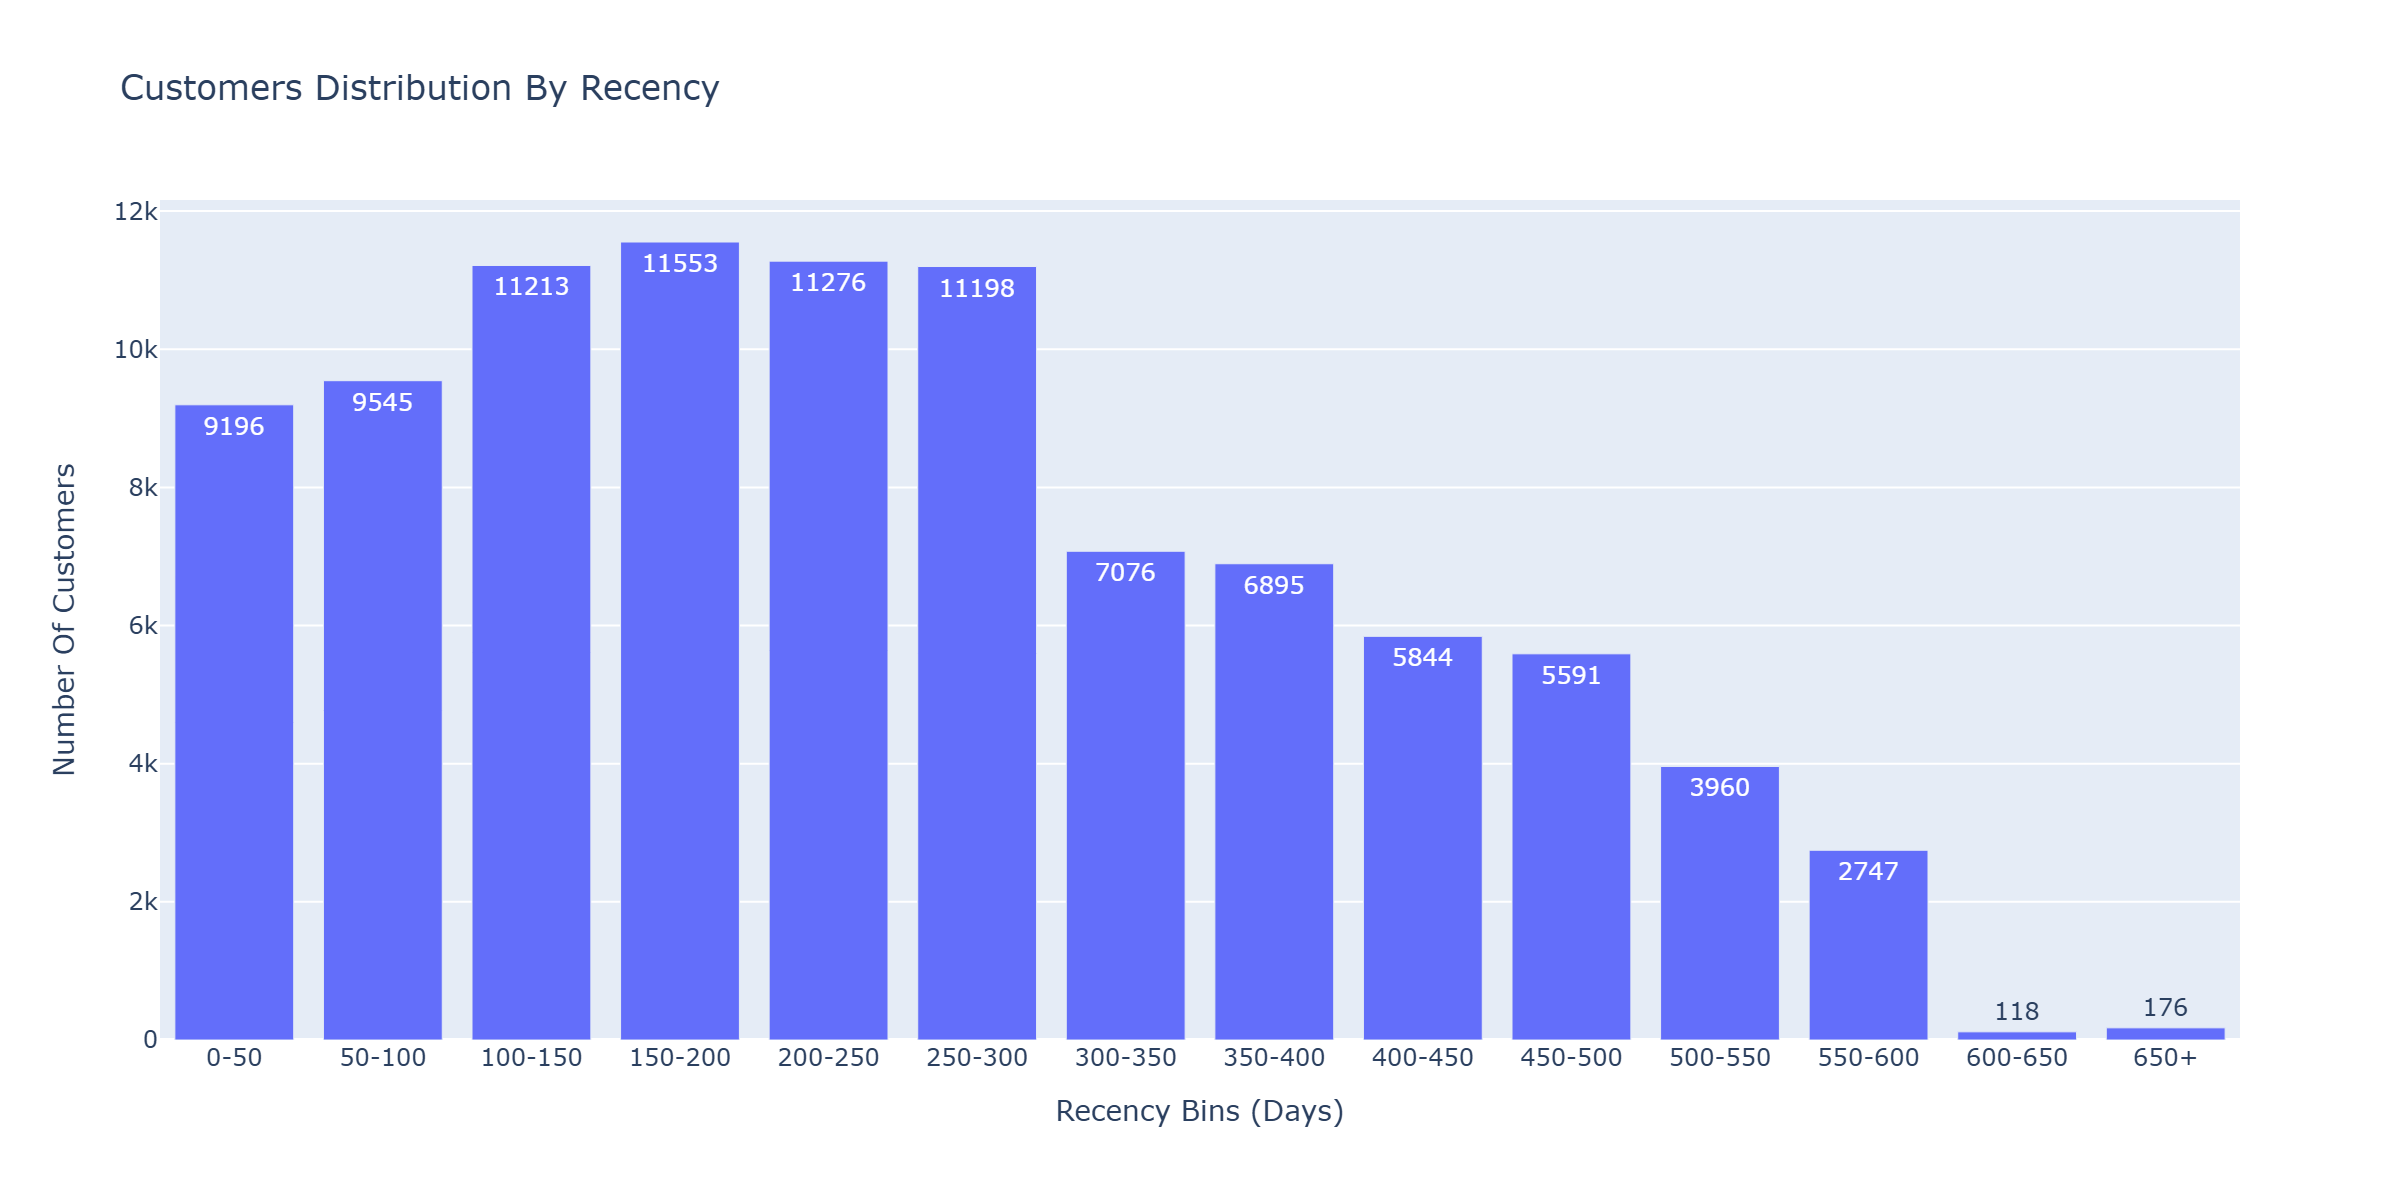

In [12]:
display(Markdown(f"""
## Recency Analysis Conclusion:

Recency measures how long it has been since a customer’s **most recent completed purchase.** 

In this analysis:
- Only orders with `delivered` status were considered to ensure revenue realization.
- **Recency** was calculated as the number of days between a customer's latest purchase timestamp and a threshold set as
`DATE(MAX(order_purchase_timestamp), '+10 days')` .i.e. **{recency_table_full['date_threshold'].iloc[0]}**. This approach was 
chosen because the dataset is historical, and using the current date would distort recency values.

- Each customer is recorded once using a `WINDOW FUNCTION` to capture their most recent purchase.

The resulting table `recency_table_full` holds the entire information at a customer level, leaving space for further
segmentation and drill-down analysis when required, `recency_table_full` holds a data of **{recency_table_full.shape[0]}** rows 
and **{recency_table_full.shape[1]}** features, as a glimpse, here is what it looks like: """))
display(recency_table_full.head(5))


display(Markdown(f"""
To improve interpretability, customers were grouped into **50-day recency bins**, allowing the analysis to be performed
at an aggregated level while preserving the underlying customer-level data:
"""))
display(customers_per_bins_labeled_df)

display(Markdown("""
The chart below visualizes the distribution of customers across recency bins, highlighting how customer activity
declines as time since last purchase increases:
"""))
fig.show()
fig.write_image("../plots/Customers_Distribution_By_Recency.png", width=1200, height=600, scale=2)
display(Image(filename="../plots/Customers_Distribution_By_Recency.png"))

## 1.2 Frequency Analysis:

- Frequency asks **"How often does a customer make a purchase?"**
- In business terms,
    - `High Frequency`: loyal customers
    - `Low Frequency`: one-time customer or chustomer who are at churn-risk


In [13]:
customer_order_frequency_interpretation_q = """
        
        WITH customer_full_IDs AS (
                                    SELECT
                                        coi.order_id, 
                                        coi.customer_id,
                                        c.customer_unique_id
                                     FROM
                                         customer_order_info coi INNER JOIN customers c
                                             ON coi.customer_id = c.customer_id
                                      ),
                                      
             
             orders_per_customer AS (
                                      SELECT
                                          customer_unique_id,
                                          COUNT(DISTINCT order_id) AS total_orders
                                      FROM
                                          customer_full_IDs
                                      GROUP BY
                                          customer_unique_id
                                     )
                                     
             SELECT
                 customer_unique_id,
                 total_orders,
                 CASE 
                     WHEN total_orders = 1 THEN 'One-Time Buyer'
                     WHEN total_orders = 2 THEN 'Returning Customer'
                     WHEN total_orders = 3 THEN 'Loyal Customer'
                     WHEN total_orders = 4 THEN 'Very Loyal'
                     ELSE 'VIP Customers'
                 END AS Interpretation                   
             FROM
                 orders_per_customer;
       """


customer_order_frequency_interpretation = pd.read_sql_query(customer_order_frequency_interpretation_q,conn)

In [14]:
customer_order_frequency_interpretation.head(3)

,customer_unique_id,total_orders,Interpretation
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-Time Buyer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-Time Buyer
2,0000f46a3911fa3c0805444483337064,1,One-Time Buyer


In [15]:
customer_order_frequency_interpretation_counts = customer_order_frequency_interpretation['Interpretation'].value_counts()
customer_order_frequency_interpretation_counts = customer_order_frequency_interpretation_counts.to_frame().reset_index()
customer_order_frequency_interpretation_counts.rename(columns={'count':'Total Counts'}, inplace=True)
customer_order_frequency_interpretation_counts['Customer Share (%)'] = np.round((customer_order_frequency_interpretation_counts['Total Counts']
                                                                        / customer_order_frequency_interpretation_counts['Total Counts'].sum()) * 100, 3)

In [16]:
customer_order_frequency_interpretation_counts[['Interpretation', 'Total Counts']]

,Interpretation,Total Counts
0,One-Time Buyer,90557
1,Returning Customer,2573
2,Loyal Customer,181
3,Very Loyal,28
4,VIP Customers,19


In [17]:
import plotly.express as px

fig = px.bar(customer_order_frequency_interpretation_counts,
             x='Interpretation',
             y='Customer Share (%)',
             text='Customer Share (%)',
             hover_data={'Total Counts': True},
             title='Customer Segmentation by Purchase Frequency',
             labels={'Interpretation':'Customer Segment', 'Customer Share (%)':'Customer Share (%)',
                    'Total Counts': 'Total Customers'})

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_yaxes(type='log')
fig.write_image("../plots/Customer_Segmentation_by_Purchase_Frequency.png", width=1200, height=600, scale=2)



## Frequency Analysis Conclusion:

Frequency measures **how often a customer makes a complete purchase**.

In this analysis:
- Only orders with `delivered` status were considered to ensure that each counted order represents a 
**completed and revenue-realized transaction**.
- Since a single customer in the OLIST dataset may have multiple `customer_id`s across different orders, 
all frequency calculations were performed at the **`customer_unique_id` level**, which represents a real-world customer.
- The frequency metric was calculated as the **number of distinct orders per customer**.

The resulting table `customer_order_frequency_interpretation` contains **one row per unique customer**, along with:
- `total_orders`: total number of completed purchases
- `Interpretation`: a business-friendly customer segment based on purchase behavior.

To make the results interpretable from a business perspective, customers were segmented as follows:

- **One-Time Buyer**: 1 order  
- **Returning Customer**: 2 orders  
- **Loyal Customer**: 3 orders  
- **Very Loyal Customer**: 4 orders  
- **VIP Customers**: 5 or more orders


,Interpretation,Total Counts,Customer Share (%)
0,One-Time Buyer,90557,97.000
1,Returning Customer,2573,2.756
2,Loyal Customer,181,0.194
3,Very Loyal,28,0.030
4,VIP Customers,19,0.020



The frequency distribution shows a **strongly right-skewed pattern**, indicating that the majority of 
customers placed only a single order:

- `One-Time Buyer`s dominate the customer base, accounting for **96.947% of all customers**
- Returning and Loyal customers form a much smaller but strategically important segment
- VIP Customers represent a very small fraction but are likely to contribute **disproportionately higher lifetime value**

To properly visualize this imbalance, a **logarithmic scale** was used in the frequency distribution chart. 
This approach prevents one-time buyers from visually overwhelming the chart and allows meaningful comparison 
between smaller yet valuable customer segments.

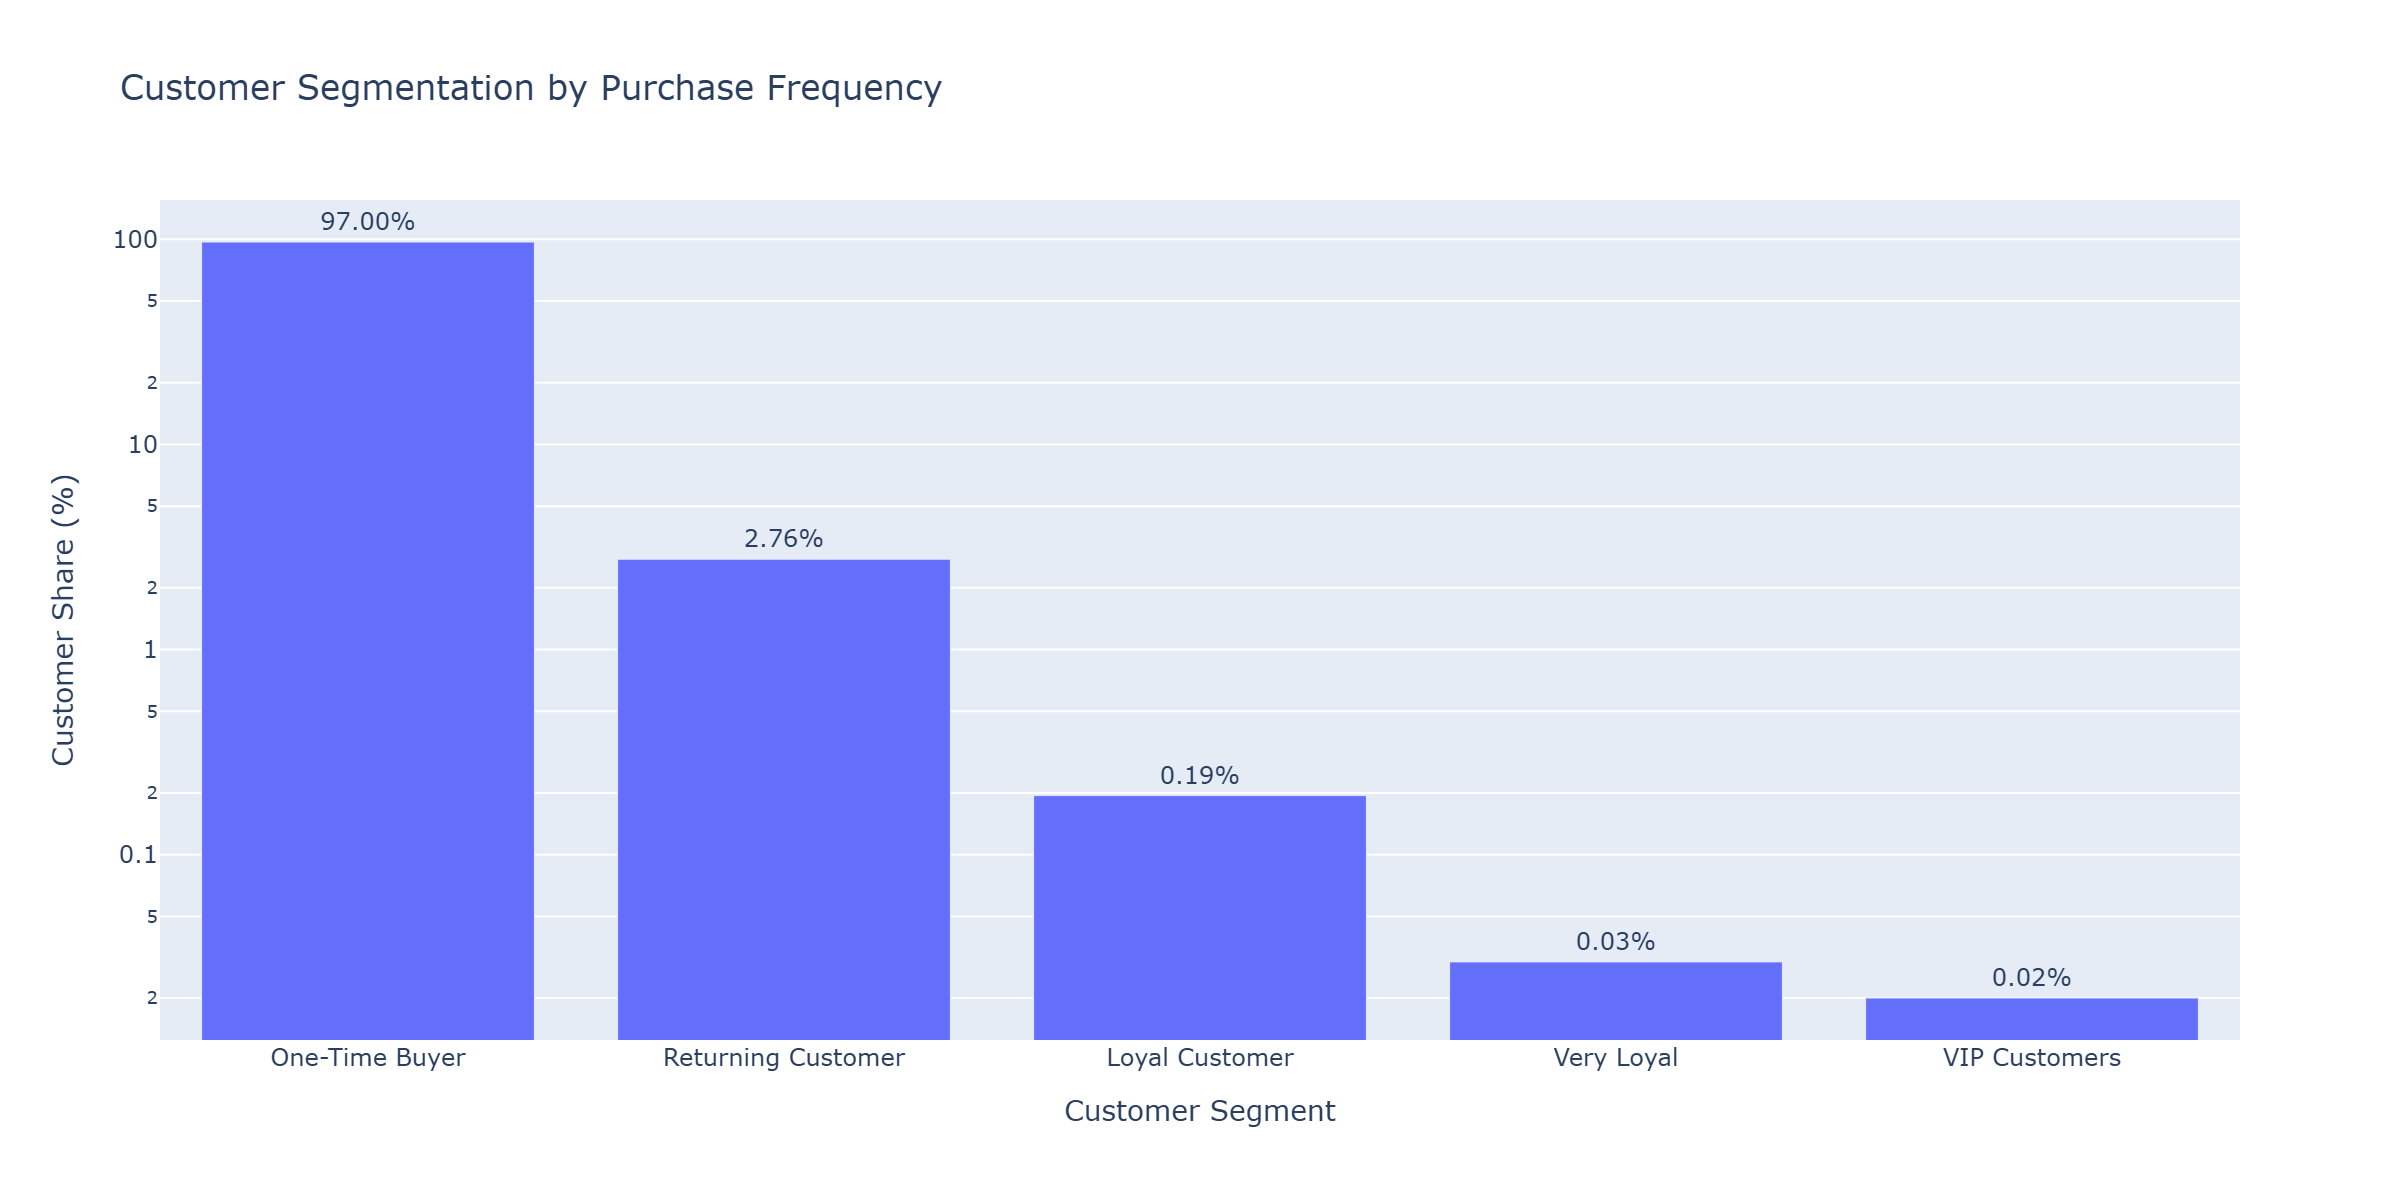


Overall, the Frequency analysis reveals that the business is highly dependent on **first-time buyers**, highlighting a significant opportunity for:
- Retention strategies
- Repeat purchase incentives
- Loyalty and CRM programs

These insights will be especially valuable when combined with **Monetary value** in the final RFM segmentation.


In [18]:
display(Markdown("""
## Frequency Analysis Conclusion:

Frequency measures **how often a customer makes a complete purchase**.

In this analysis:
- Only orders with `delivered` status were considered to ensure that each counted order represents a 
**completed and revenue-realized transaction**.
- Since a single customer in the OLIST dataset may have multiple `customer_id`s across different orders, 
all frequency calculations were performed at the **`customer_unique_id` level**, which represents a real-world customer.
- The frequency metric was calculated as the **number of distinct orders per customer**.

The resulting table `customer_order_frequency_interpretation` contains **one row per unique customer**, along with:
- `total_orders`: total number of completed purchases
- `Interpretation`: a business-friendly customer segment based on purchase behavior.

To make the results interpretable from a business perspective, customers were segmented as follows:

- **One-Time Buyer**: 1 order  
- **Returning Customer**: 2 orders  
- **Loyal Customer**: 3 orders  
- **Very Loyal Customer**: 4 orders  
- **VIP Customers**: 5 or more orders
"""))

display(customer_order_frequency_interpretation_counts)


display(Markdown(f"""
The frequency distribution shows a **strongly right-skewed pattern**, indicating that the majority of 
customers placed only a single order:

- `One-Time Buyer`s dominate the customer base, accounting for **96.947% of all customers**
- Returning and Loyal customers form a much smaller but strategically important segment
- VIP Customers represent a very small fraction but are likely to contribute **disproportionately higher lifetime value**

To properly visualize this imbalance, a **logarithmic scale** was used in the frequency distribution chart. 
This approach prevents one-time buyers from visually overwhelming the chart and allows meaningful comparison 
between smaller yet valuable customer segments."""))

fig.show()
display(Image(filename="../plots/Customer_Segmentation_by_Purchase_Frequency.png"))
        
display(Markdown("""
Overall, the Frequency analysis reveals that the business is highly dependent on **first-time buyers**, highlighting a significant opportunity for:
- Retention strategies
- Repeat purchase incentives
- Loyalty and CRM programs

These insights will be especially valuable when combined with **Monetary value** in the final RFM segmentation.
"""))

## 1.3 Monetary Analysis:

- Monetary asks **"How much money did each customer spend in total??"**
- This answers:
    - Who are the highest-value customers?
    - Who looks loyal but actually spends very little?
    - Who spends a lot but purchases infrequently?


In [19]:
q = "SELECT * FROM customers LIMIT 2;"
pd.read_sql_query(q, conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [20]:
total_spendings_per_customer_q = """
    WITH order_info AS (
                        SELECT
                             oi.order_id,
                             (oi.price + oi.freight_value) AS total_amount,
                             o.customer_id
                        FROM
                            order_items oi INNER JOIN orders o
                                ON oi.order_id = o.order_id
                        WHERE
                            o.order_status = 'delivered')
                            
                            
         SELECT
             c.customer_unique_id,
             SUM(o_info.total_amount) AS total_amount
         FROM
             order_info o_info INNER JOIN customers c
                 ON o_info.customer_id = c.customer_id
         GROUP BY c.customer_unique_id
         ORDER BY SUM(o_info.total_amount) DESC;
    
    """
total_spendings_per_customer = pd.read_sql_query(total_spendings_per_customer_q, conn)

In [21]:
total_spendings_per_customer.shape

(93358, 2)

In [22]:
customer_order_frequency_interpretation.shape

(93358, 3)

In [23]:
total_frequency_and_total_amount = pd.merge(customer_order_frequency_interpretation, 
               total_spendings_per_customer, how='inner')

In [24]:
total_frequency_and_total_amount.head(3)

,customer_unique_id,total_orders,Interpretation,total_amount
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-Time Buyer,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-Time Buyer,27.19
2,0000f46a3911fa3c0805444483337064,1,One-Time Buyer,86.22


In [25]:
segment_monetary_summary = (
    total_frequency_and_total_amount
        .groupby('Interpretation')
        .agg(
            total_customers=('customer_unique_id', 'nunique'),
            total_revenue=('total_amount', 'sum'),
            avg_revenue_per_customer=('total_amount', 'mean')
        )
        .reset_index()
        .sort_values(by='total_revenue', ascending=False)
)

In [26]:
segment_monetary_summary

,Interpretation,total_customers,total_revenue,avg_revenue_per_customer
1,One-Time Buyer,90557,14555586.29,160.733972
2,Returning Customer,2573,748811.57,291.026650
0,Loyal Customer,181,78333.95,432.784254
4,Very Loyal,28,22086.25,788.794643
3,VIP Customers,19,14955.69,787.141579


In [27]:
segment_monetary_summary_w_customer_share = pd.merge(segment_monetary_summary,
                                                    customer_order_frequency_interpretation_counts,
                                                    how='inner').drop(columns=['Total Counts'])
segment_monetary_summary_w_customer_share = (segment_monetary_summary_w_customer_share
                                             .rename(columns={'total_customers':'Total Customers',
                                                             'total_revenue': 'Total Revenue',
                                                             'avg_revenue_per_customer': 'Average Revenue Per Customer',
                                                             'Customer Share (%)':'Revenue Contribution (%)'}))

In [28]:
segment_monetary_summary_w_customer_share

,Interpretation,Total Customers,Total Revenue,Average Revenue Per Customer,Revenue Contribution (%)
0,One-Time Buyer,90557,14555586.29,160.733972,97.000
1,Returning Customer,2573,748811.57,291.026650,2.756
2,Loyal Customer,181,78333.95,432.784254,0.194
3,Very Loyal,28,22086.25,788.794643,0.030
4,VIP Customers,19,14955.69,787.141579,0.020


In [37]:
def volume_vs_value_chart():
    """
    This function will be responsible to display a bar and a line chart that compares the revenue based on Volume and Value:
    """
    fig = go.Figure()

    # Adding the Total Revenue:
    fig.add_bar(
        x=segment_monetary_summary_w_customer_share['Interpretation'],
        y=segment_monetary_summary_w_customer_share['Total Revenue'],
        customdata=segment_monetary_summary_w_customer_share[['Total Customers', 'Revenue Contribution (%)']],
        marker=dict(
            color=np.log10(segment_monetary_summary_w_customer_share['Total Revenue']),
            colorscale='Blugrn',
            showscale=True,
            colorbar=dict(x=-0.15,
                          xanchor='left',
                          len=1,
                          thickness=20,
                          tickvals=[])
        ),
        name='Total Revenue',
        text=[f'{val/1000000:.2f}M' if val >= 1000000 
              else f'{val/1000:.0f}K' if val >= 1000 
              else f'{val:.0f}' 
              for val in segment_monetary_summary_w_customer_share['Total Revenue']],
        textposition='outside',
        textfont=dict(size=12, color='black')
    )

    # Adding the Average Revenue Per Person:
    fig.add_scatter(
        x=segment_monetary_summary_w_customer_share['Interpretation'],
        y=segment_monetary_summary_w_customer_share['Average Revenue Per Customer'],
        name='Avg Revenue per Customer',
        text = [f"{avg_rev:.2f}" for avg_rev in segment_monetary_summary_w_customer_share['Average Revenue Per Customer']],
        textposition='top center',
        textfont=dict(size=12, color='black'),
        customdata=segment_monetary_summary_w_customer_share[['Total Customers', 'Revenue Contribution (%)']],
        yaxis='y2',
         marker=dict(
            color=(segment_monetary_summary_w_customer_share['Average Revenue Per Customer']),
            colorscale='OrRd',
            showscale=True,
            colorbar=dict(len=1,
                          xanchor='right',
                          x=1.15,
                          thickness=20,
                          tickvals=[])
        ),
        mode='lines+markers+text'
    )

    fig.update_layout(
        title='Revenue Contribution <b>Volume</b> vs Customer <b>Value</b> by Frequency Segment in Brazilian Real <b>($R)</b>',
        xaxis_title='Customer Segment',
        yaxis=dict(
            title='Total Revenue',
            type='log',
            tickmode='array',
            tickvals=[1000, 10000, 100000, 1000000, 10000000],
            ticktext=['1K', '10K', '100K', '1M', '10M'],
            showgrid=True
        ),
        yaxis2=dict(
            title='Avg Revenue per Customer',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='top',
            y=-0.25,
            xanchor='center',
            x=0.5
        )
    )
    fig.update_traces(
        selector=dict(type='bar'),
        hoverlabel=dict( bgcolor='white'),
        hovertemplate= 
        "<b>Total Customers:</b> %{customdata[0]:,}<br>"+
        "<b>Total Revenue:</b> %{y:,.2f} $R<br>" +
        "<b>Revenue Contribution (%):</b> %{customdata[1]:,.2f}%<br>"+
        "<extra></extra>"
    )
    fig.update_traces(
        selector=dict(type='scatter'),
        hoverlabel=dict(
        bgcolor='white',
        font_size=14
        ),
        hovertemplate=
        "<b>Total Customers:</b> %{customdata[0]:,}<br>"+
        "<b>Average Revenue Per Customer:</b> %{y:,.2f} $R<br>" +
        "<b>Revenue Contribution (%):</b> %{customdata[1]:,.2f}%<br>"+
        "<extra></extra>"
    )
    
    return fig




## Monetary Analysis Conclusion:

Monetary analysis focuses on understanding **how much revenue customers generate**, not just how often they purchase.
While Frequency identifies repeat behavior, **Monetary highlights customer value**.

In this analysis:
- Only **delivered orders** were considered to ensure that revenue reflects completed transactions.
- Monetary value was calculated at the **order item level** to capture the true transaction amount, then aggregated to the
  `customer_unique_id` level.
- The monetary data was joined with the previously defined **Frequency-based customer segments**, allowing revenue
  contribution and customer value to be analyzed together.

,Interpretation,Total Customers,Total Revenue,Average Revenue Per Customer,Revenue Contribution (%)
0,One-Time Buyer,90557,14555586.29,160.733972,97.000
1,Returning Customer,2573,748811.57,291.026650,2.756
2,Loyal Customer,181,78333.95,432.784254,0.194
3,Very Loyal,28,22086.25,788.794643,0.030
4,VIP Customers,19,14955.69,787.141579,0.020


The chart below displays the comparison between the <b>Volume</b> and <b>Value</b>

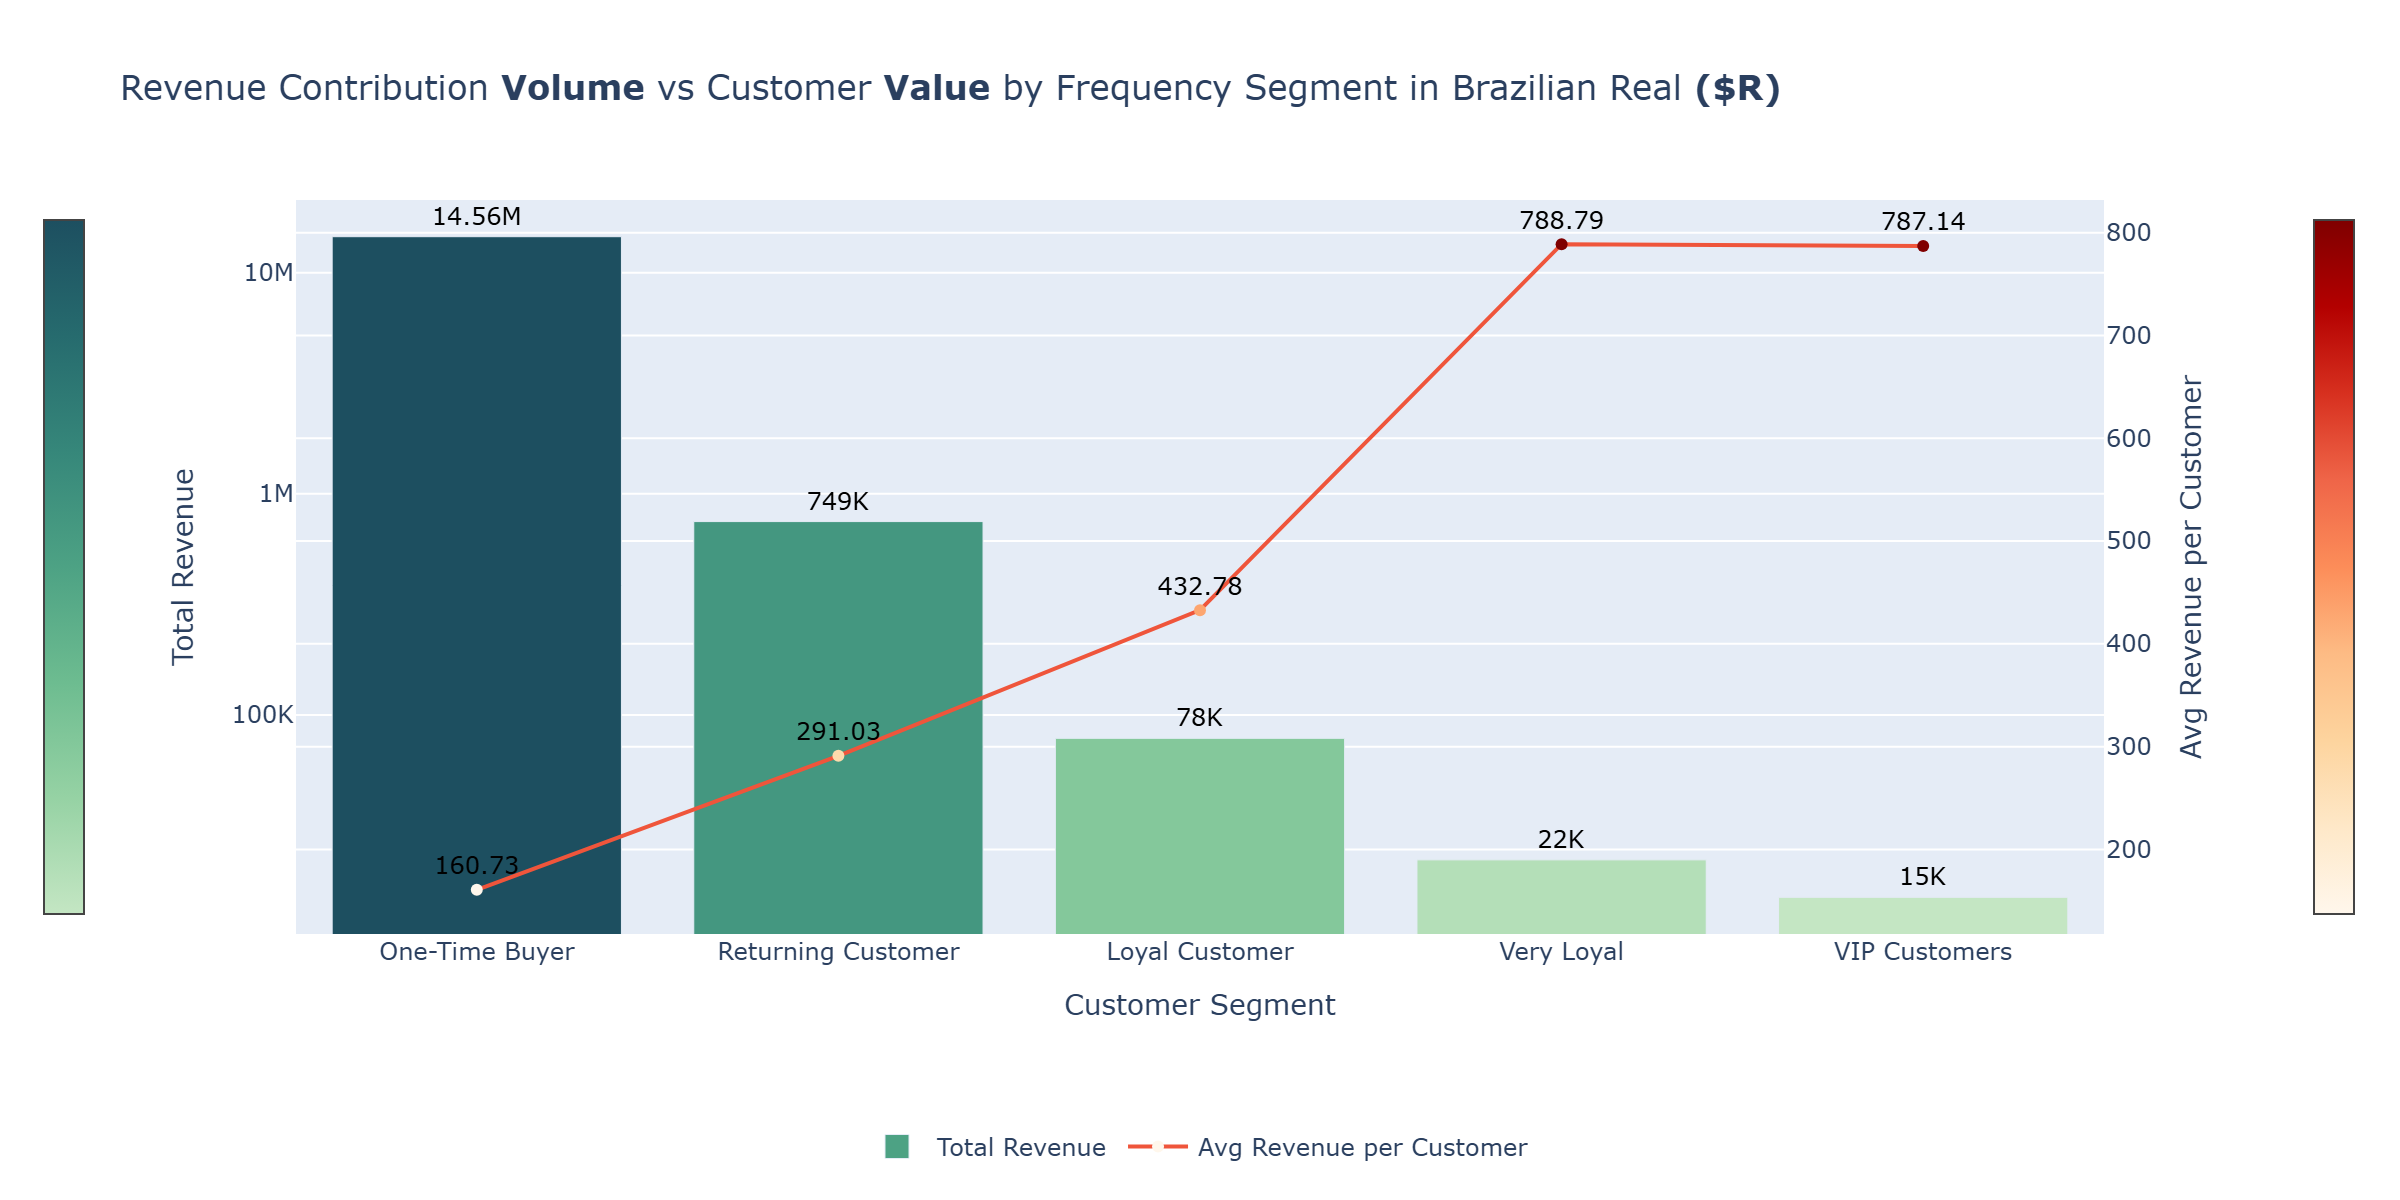

    

### Key Findings:

- **One-Time Buyers** generate the **highest total revenue** overall, primarily due to their overwhelming volume
  (≈97% of the customer base), despite having the **lowest average revenue per customer**.
- **Returning, Loyal, and Very Loyal customers**, although significantly fewer in number, contribute **progressively higher
  average revenue per customer**, indicating stronger individual customer value.
- **VIP Customers** represent the smallest segment but show **one of the highest average revenues per customer**,
  highlighting their importance from a long-term value perspective rather than volume.
- The contrast between **total revenue (volume-driven)** and **average revenue per customer (value-driven)** reveals that
  revenue concentration alone can be misleading without considering customer quality.

### Business Interpretation:

- Revenue is currently **volume-driven**, dominated by One-Time Buyers.
- However, **high-frequency segments deliver disproportionately higher value per customer**, making them ideal targets
  for:
  - Retention strategies
  - Personalized marketing
  - Loyalty and reward programs

The final visualization effectively demonstrates this dual perspective by:
- Using **Log₁₀ scaled total revenue** to highlight revenue concentration.
- Overlaying **average revenue per customer** to reveal customer value across segments.

This analysis reinforces the importance of balancing **customer acquisition** with **customer retention and value growth**
to build a sustainable revenue strategy.


In [38]:
display(Markdown(f"""
## Monetary Analysis Conclusion:

Monetary analysis focuses on understanding **how much revenue customers generate**, not just how often they purchase.
While Frequency identifies repeat behavior, **Monetary highlights customer value**.

In this analysis:
- Only **delivered orders** were considered to ensure that revenue reflects completed transactions.
- Monetary value was calculated at the **order item level** to capture the true transaction amount, then aggregated to the
  `customer_unique_id` level.
- The monetary data was joined with the previously defined **Frequency-based customer segments**, allowing revenue
  contribution and customer value to be analyzed together."""))
        
display(segment_monetary_summary_w_customer_share)
        
display(Markdown("The chart below displays the comparison between the <b>Volume</b> and <b>Value</b>"))
fig = volume_vs_value_chart()
fig.show()
fig.write_image("../plots/Revenue_contribution_volume_vs_value.png", width=1200, height=600, scale=2)
display(Image(filename="../plots/Revenue_contribution_volume_vs_value.png"))
display(Markdown("""    

### Key Findings:

- **One-Time Buyers** generate the **highest total revenue** overall, primarily due to their overwhelming volume
  (≈97% of the customer base), despite having the **lowest average revenue per customer**.
- **Returning, Loyal, and Very Loyal customers**, although significantly fewer in number, contribute **progressively higher
  average revenue per customer**, indicating stronger individual customer value.
- **VIP Customers** represent the smallest segment but show **one of the highest average revenues per customer**,
  highlighting their importance from a long-term value perspective rather than volume.
- The contrast between **total revenue (volume-driven)** and **average revenue per customer (value-driven)** reveals that
  revenue concentration alone can be misleading without considering customer quality.

### Business Interpretation:

- Revenue is currently **volume-driven**, dominated by One-Time Buyers.
- However, **high-frequency segments deliver disproportionately higher value per customer**, making them ideal targets
  for:
  - Retention strategies
  - Personalized marketing
  - Loyalty and reward programs

The final visualization effectively demonstrates this dual perspective by:
- Using **Log₁₀ scaled total revenue** to highlight revenue concentration.
- Overlaying **average revenue per customer** to reveal customer value across segments.

This analysis reinforces the importance of balancing **customer acquisition** with **customer retention and value growth**
to build a sustainable revenue strategy.
"""))
